# Stage 02: Professional Regression Benchmark

### Goals
- Compare a broader set of regression models
- Select the best model using test and cross-validation metrics

In [3]:
# Imports all required libraries for data handling, modeling, metrics, plots, and artifact saving.
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)


In [4]:
# Sets file paths, prepares output folders, and removes old legacy output images.
PROJECT_ROOT = Path("..").resolve()
STAGE_DIR = Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "usedcars.csv"

OUTPUT_DIR = STAGE_DIR / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
METRICS_DIR = OUTPUT_DIR / "metrics"
MODELS_DIR = OUTPUT_DIR / "models"

for directory in [OUTPUT_DIR, FIGURES_DIR, METRICS_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Dataset path: {DATA_PATH}")
print(f"Output root: {OUTPUT_DIR}")


Dataset path: C:\Users\a12u\OneDrive\Desktop\Courses\Own Projects\used-car-price-intelligence-platform\data\usedcars.csv
Output root: c:\Users\a12u\OneDrive\Desktop\Courses\Own Projects\used-car-price-intelligence-platform\02-baseline-modeling\outputs


In [5]:
# Loads the dataset, enforces numeric conversion, and prepares cleaned features and target variables.
df = pd.read_csv(DATA_PATH)

target_col = "price"
if target_col not in df.columns:
    raise ValueError("Target column 'price' is missing.")

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col != target_col]

dataset = df[feature_cols + [target_col]].dropna(subset=[target_col]).copy()
X = dataset[feature_cols]
y = dataset[target_col]

print(f"Rows: {len(dataset)}")
print(f"Features ({len(feature_cols)}): {feature_cols}")
dataset.head()


Rows: 500
Features (28): ['symboling', 'normalized-losses', 'make', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'city-L/100km', 'horsepower-binned', 'diesel', 'gas']


,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,city-L/100km,horsepower-binned,diesel,gas,price
0,3,122,NaN,NaN,NaN,NaN,NaN,NaN,88.6,0.811148,0.890278,48.8,2548,NaN,NaN,130,NaN,3.47,2.68,9.0,111.0,5000.0,21,27,11.190476,NaN,0,1,13495.0
1,3,122,NaN,NaN,NaN,NaN,NaN,NaN,88.6,0.811148,0.890278,48.8,2548,NaN,NaN,130,NaN,3.47,2.68,9.0,111.0,5000.0,21,27,11.190476,NaN,0,1,16500.0
2,1,122,NaN,NaN,NaN,NaN,NaN,NaN,94.5,0.822681,0.909722,52.4,2823,NaN,NaN,152,NaN,2.68,3.47,9.0,154.0,5000.0,19,26,12.368421,NaN,0,1,16500.0
3,2,164,NaN,NaN,NaN,NaN,NaN,NaN,99.8,0.848630,0.919444,54.3,2337,NaN,NaN,109,NaN,3.19,3.40,10.0,102.0,5500.0,24,30,9.791667,NaN,0,1,13950.0
4,2,164,NaN,NaN,NaN,NaN,NaN,NaN,99.4,0.848630,0.922222,54.3,2824,NaN,NaN,136,NaN,3.19,3.40,8.0,115.0,5500.0,18,22,13.055556,NaN,0,1,17450.0


In [6]:
# Splits data and defines all candidate regression pipelines to be benchmarked.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def linear_pipeline(estimator):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", estimator),
    ])

def tree_pipeline(estimator):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", estimator),
    ])

models = {
    "Linear Regression": linear_pipeline(LinearRegression()),
    "Ridge Regression": linear_pipeline(Ridge(alpha=1.0, random_state=42)),
    "Lasso Regression": linear_pipeline(Lasso(alpha=0.001, max_iter=20000, random_state=42)),
    "ElasticNet Regression": linear_pipeline(ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=20000, random_state=42)),
    "Polynomial Regression (deg=2)": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("model", LinearRegression()),
    ]),
    "Polynomial Regression (deg=3)": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=3, include_bias=False)),
        ("model", Ridge(alpha=1.0, random_state=42)),
    ]),
    "Random Forest": tree_pipeline(RandomForestRegressor(
        n_estimators=500, min_samples_leaf=2, random_state=42, n_jobs=-1
    )),
    "Gradient Boosting": tree_pipeline(GradientBoostingRegressor(random_state=42)),
}

print(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
print(f"Models compared: {len(models)}")


Train rows: 400, Test rows: 100
Models compared: 8


In [8]:
# Trains and evaluates each model with cross-validation and test metrics, then saves the comparison table.
cv = KFold(n_splits=5, shuffle=True, random_state=42)
results = []
trained_models = {}

for model_name, model in models.items():
    model_instance = clone(model)

    cv_result = cross_validate(
        model_instance,
        X_train,
        y_train,
        scoring={
            "r2": "r2",
            "neg_rmse": "neg_root_mean_squared_error",
            "neg_mae": "neg_mean_absolute_error",
        },
        cv=cv,
        n_jobs=-1,
        return_train_score=False,
    )

    model_instance.fit(X_train, y_train)
    y_pred_test = model_instance.predict(X_test)

    results.append({
        "model": model_name,
        "cv_r2_mean": float(np.mean(cv_result["test_r2"])),
        "cv_r2_std": float(np.std(cv_result["test_r2"])),
        "cv_rmse_mean": float(-np.mean(cv_result["test_neg_rmse"])),
        "cv_mae_mean": float(-np.mean(cv_result["test_neg_mae"])),
        "test_r2": float(r2_score(y_test, y_pred_test)),
        "test_rmse": float(np.sqrt(mean_squared_error(y_test, y_pred_test))),
        "test_mae": float(mean_absolute_error(y_test, y_pred_test)),
    })

    trained_models[model_name] = model_instance

comparison_df = pd.DataFrame(results).sort_values(
    by=["test_rmse", "test_r2"],
    ascending=[True, False]
).reset_index(drop=True)

comparison_path = METRICS_DIR / "model_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)

comparison_df

,model,cv_r2_mean,cv_r2_std,cv_rmse_mean,cv_mae_mean,test_r2,test_rmse,test_mae
0,Gradient Boosting,0.956805,0.018524,1413.355063,924.066031,0.960482,1841.788644,1082.223360
1,Random Forest,0.945452,0.042902,1523.476526,952.592356,0.930506,2442.401559,1253.371944
2,Ridge Regression,0.848964,0.027248,2691.125217,1964.526877,0.861428,3448.904975,2363.930174
3,ElasticNet Regression,0.848093,0.027306,2698.779155,1966.359156,0.860352,3462.272383,2362.533400
4,Lasso Regression,0.847849,0.027277,2700.995735,1966.925566,0.860006,3466.557694,2362.039044
5,Linear Regression,0.847849,0.027277,2700.997099,1966.925555,0.860006,3466.563128,2362.038696
6,Polynomial Regression (deg=2),0.736805,0.241961,3194.534747,1256.521384,0.398691,7184.439321,2488.186884
7,Polynomial Regression (deg=3),0.874652,0.168947,2055.315868,866.016068,0.110150,8739.821358,2013.124355


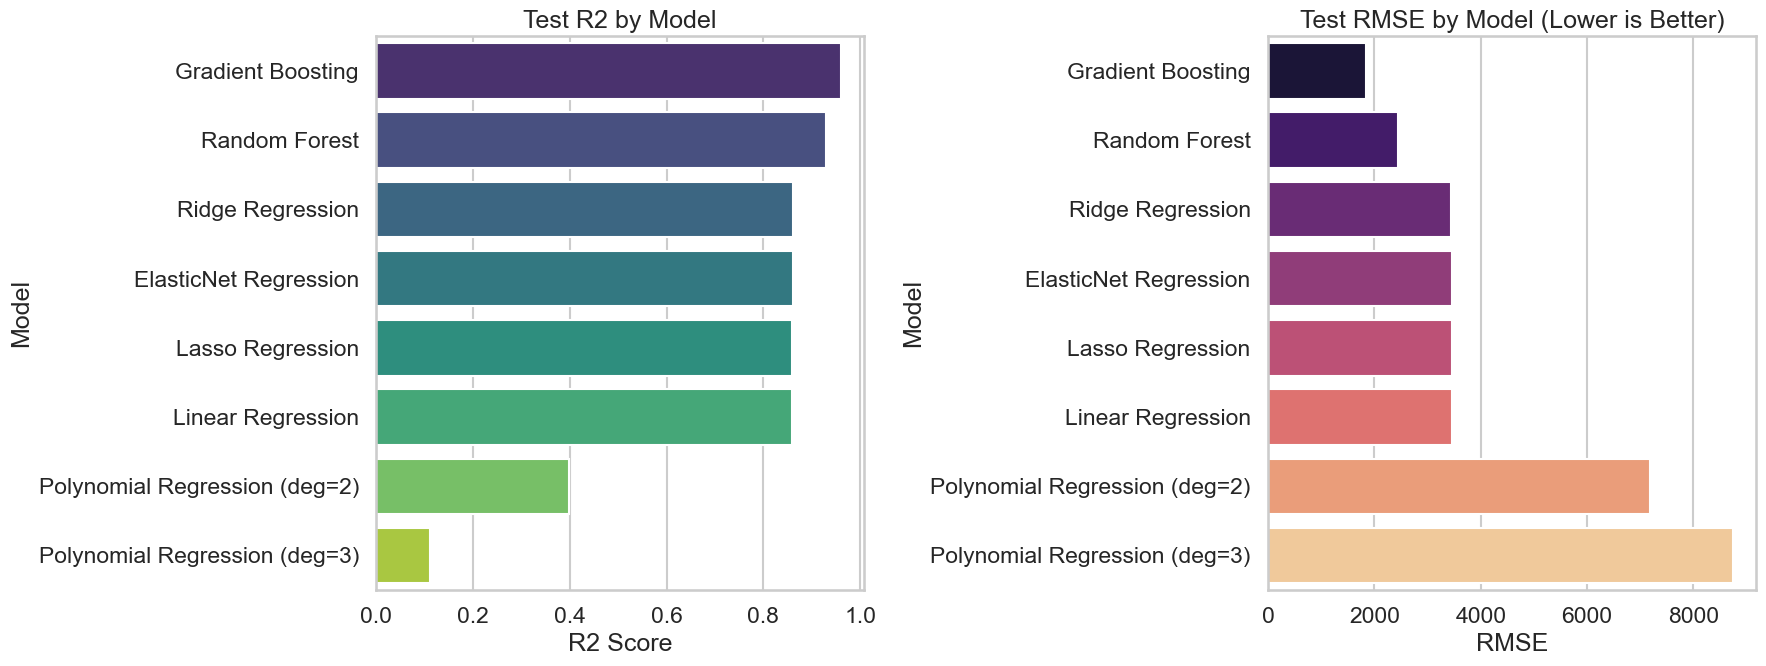

In [9]:
# Visualizes side-by-side benchmark charts for R2 and RMSE across models.
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=comparison_df, x="test_r2", y="model", ax=axes[0], palette="viridis")
axes[0].set_title("Test R2 by Model")
axes[0].set_xlabel("R2 Score")
axes[0].set_ylabel("Model")

sns.barplot(data=comparison_df, x="test_rmse", y="model", ax=axes[1], palette="magma")
axes[1].set_title("Test RMSE by Model (Lower is Better)")
axes[1].set_xlabel("RMSE")
axes[1].set_ylabel("Model")

plt.tight_layout()
comparison_plot_path = FIGURES_DIR / "model_comparison_bars.png"
plt.savefig(comparison_plot_path, dpi=300, bbox_inches="tight")
plt.show()


In [11]:
# Selects the best model by RMSE, saves metrics JSON and serialized model artifact.
best_row = comparison_df.iloc[0]
best_model_name = best_row["model"]
best_model = trained_models[best_model_name]

best_pred = best_model.predict(X_test)

best_metrics = {
    "best_model": best_model_name,
    "test_r2": float(r2_score(y_test, best_pred)),
    "test_rmse": float(np.sqrt(mean_squared_error(y_test, best_pred))),
    "test_mae": float(mean_absolute_error(y_test, best_pred)),
}

best_metrics_path = METRICS_DIR / "best_model_metrics.json"
with open(best_metrics_path, "w", encoding="utf-8") as f:
    json.dump(best_metrics, f, indent=2)

model_path = MODELS_DIR / "best_model.joblib"
joblib.dump(best_model, model_path)

print("Best model:", best_model_name)
print("Saved metrics:", best_metrics_path)
print("Saved model:", model_path)

Best model: Gradient Boosting
Saved metrics: c:\Users\a12u\OneDrive\Desktop\Courses\Own Projects\used-car-price-intelligence-platform\02-baseline-modeling\outputs\metrics\best_model_metrics.json
Saved model: c:\Users\a12u\OneDrive\Desktop\Courses\Own Projects\used-car-price-intelligence-platform\02-baseline-modeling\outputs\models\best_model.joblib


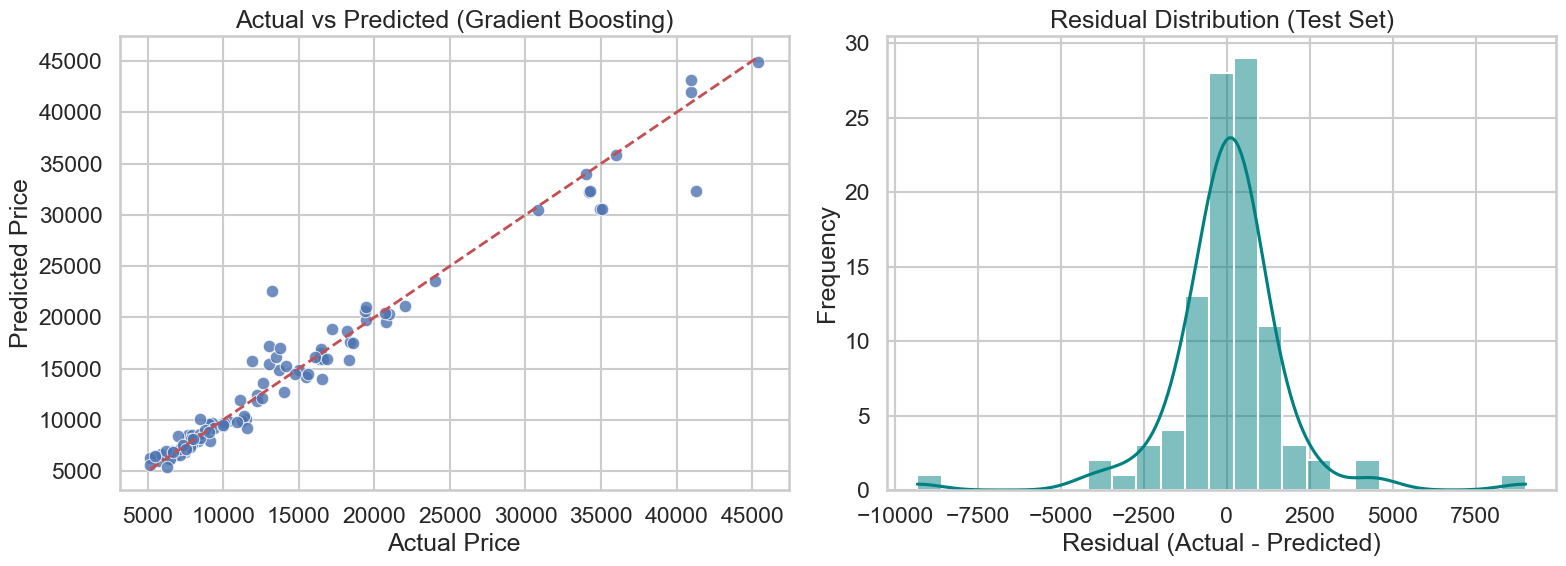

In [12]:
# Generates and saves diagnostics for the best model (prediction fit and residual distribution).
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x=y_test, y=best_pred, alpha=0.8, ax=axes[0])
line_min = min(y_test.min(), best_pred.min())
line_max = max(y_test.max(), best_pred.max())
axes[0].plot([line_min, line_max], [line_min, line_max], "r--", linewidth=2)
axes[0].set_title(f"Actual vs Predicted ({best_model_name})")
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")

residuals = y_test - best_pred
sns.histplot(residuals, bins=25, kde=True, ax=axes[1], color="teal")
axes[1].set_title("Residual Distribution (Test Set)")
axes[1].set_xlabel("Residual (Actual - Predicted)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
best_plot_path = FIGURES_DIR / "best_model_diagnostics.png"
plt.savefig(best_plot_path, dpi=300, bbox_inches="tight")
plt.show()


In [13]:
# Saves the best model and metrics files so results can be reused outside the notebook.
model_path = MODELS_DIR / "best_model.joblib"
metrics_path = METRICS_DIR / "best_model_metrics.json"

joblib.dump(best_model, model_path)
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(best_metrics, f, indent=2)

print(f"Saved comparison table: {comparison_path}")
print(f"Saved metrics JSON:    {metrics_path}")
print(f"Saved best model:      {model_path}")
print(f"Saved figures folder:  {FIGURES_DIR}")


Saved comparison table: c:\Users\a12u\OneDrive\Desktop\Courses\Own Projects\used-car-price-intelligence-platform\02-baseline-modeling\outputs\metrics\model_comparison.csv
Saved metrics JSON:    c:\Users\a12u\OneDrive\Desktop\Courses\Own Projects\used-car-price-intelligence-platform\02-baseline-modeling\outputs\metrics\best_model_metrics.json
Saved best model:      c:\Users\a12u\OneDrive\Desktop\Courses\Own Projects\used-car-price-intelligence-platform\02-baseline-modeling\outputs\models\best_model.joblib
Saved figures folder:  c:\Users\a12u\OneDrive\Desktop\Courses\Own Projects\used-car-price-intelligence-platform\02-baseline-modeling\outputs\figures


## Summary

The notebook now benchmarks multiple model types and automatically saves outputs into structured folders under `outputs/`.

Run all cells to generate: comparison CSV, best-model JSON, serialized model, and diagnostic plots.
